# **Import dataset**

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"windaayumelati","key":"03748c9e298dbec2b99f164a2b651ba9"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!ls ~/.kaggle

kaggle.json


In [ ]:
!kaggle datasets download -d windaayumelati/daun-tanaman-herbal

Dataset URL: https://www.kaggle.com/datasets/windaayumelati/daun-tanaman-herbal
License(s): unknown
  0% 0.00/52.8M [00:00<?, ?B/s]
100% 52.8M/52.8M [00:00<00:00, 659MB/s]


In [ ]:
!mkdir daun-tanaman-herbal
!unzip daun-tanaman-herbal.zip -d daun-tanaman-herbal
!ls daun-tanaman-herbal

Streaming output truncated to the last 5000 lines.
  inflating: daun-tanaman-herbal/Dataset Tanaman Herbal/Daun Herbal/Data Testing/Daun Jambu Biji/Daun Jambu Biji 402.jpg  
  inflating: daun-tanaman-herbal/Dataset Tanaman Herbal/Daun Herbal/Data Testing/Daun Jambu Biji/Daun Jambu Biji 403.jpg  
  inflating: daun-tanaman-herbal/Dataset Tanaman Herbal/Daun Herbal/Data Testing/Daun Jambu Biji/Daun Jambu Biji 404.jpg  
  inflating: daun-tanaman-herbal/Dataset Tanaman Herbal/Daun Herbal/Data Testing/Daun Jambu Biji/Daun Jambu Biji 405.jpg  
  inflating: daun-tanaman-herbal/Dataset Tanaman Herbal/Daun Herbal/Data Testing/Daun Jambu Biji/Daun Jambu Biji 406.jpg  
  inflating: daun-tanaman-herbal/Dataset Tanaman Herbal/Daun Herbal/Data Testing/Daun Jambu Biji/Daun Jambu Biji 407.jpg  
  inflating: daun-tanaman-herbal/Dataset Tanaman Herbal/Daun Herbal/Data Testing/Daun Jambu Biji/Daun Jambu Biji 408.jpg  
  inflating: daun-tanaman-herbal/Dataset Tanaman Herbal/Daun Herbal/Data Testing/Daun Ja

# **Import library**

In [ ]:
# Import necessary libraries
import os
import pandas as pd # Import pandas
import matplotlib.pyplot as plt # Import matplotlib for plotting
import shutil # Import shutil for file operations
import random  # Import the random module
from PIL import Image # Import Image from PIL
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator # Import ImageDataGenerator
import numpy as np # Import numpy
import tensorflow as tf # Import tensorflow
from tensorflow.keras.applications import InceptionV3 # Import InceptionV3
from tensorflow.keras.models import Sequential # Import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout # Import layers
from tensorflow.keras.regularizers import l2 # Import l2 regularizer
from tensorflow.keras.optimizers import Adamax # Import Adamax optimizer
from tensorflow.keras.utils import plot_model # Import plot_model
from tensorflow.keras.callbacks import EarlyStopping # Import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report # Import metrics
import seaborn as sns # Import seaborn
import cv2 # Import cv2

# **Data Understanding**

## Identifikasi Data

In [ ]:
# Path asal dataset
train_dir = "/content/daun-tanaman-herbal/Dataset Tanaman Herbal/Daun Herbal/Data Training"
test_dir = "/content/daun-tanaman-herbal/Dataset Tanaman Herbal/Daun Herbal/Data Testing"

# Path baru untuk semua data digabung
merged_dir = "/content/daun-tanaman-herbal/Dataset Tanaman Herbal/Daun Herbal/Dataset"

# Buat folder merged_dir kalau belum ada
os.makedirs(merged_dir, exist_ok=True)

def copy_data(source_dir, destination_dir):
    for label in os.listdir(source_dir):
        label_path = os.path.join(source_dir, label)
        if os.path.isdir(label_path):
            # Buat subfolder untuk setiap label di Dataset/
            target_label_path = os.path.join(destination_dir, label)
            os.makedirs(target_label_path, exist_ok=True)

            # Copy semua gambar
            for img_file in os.listdir(label_path):
                src_file = os.path.join(label_path, img_file)
                dst_file = os.path.join(target_label_path, img_file)
                if not os.path.exists(dst_file):  # Hindari overwrite
                    shutil.copy2(src_file, dst_file)

# Copy dari Data Training dan Data Testing
copy_data(train_dir, merged_dir)
copy_data(test_dir, merged_dir)

# Hapus folder lama setelah data berhasil digabung
shutil.rmtree(train_dir)
shutil.rmtree(test_dir)

print("Semua gambar berhasil digabung ke:", merged_dir)
print("Folder lama 'Data Training' dan 'Data Testing' telah dihapus.")


Semua gambar berhasil digabung ke: /content/daun-tanaman-herbal/Dataset Tanaman Herbal/Daun Herbal/Dataset
Folder lama 'Data Training' dan 'Data Testing' telah dihapus.


In [ ]:
# Membuat DataFrame dari folder Dataset
def load_merged_data(merged_dir):
    data = []
    for label in os.listdir(merged_dir):
        label_folder = os.path.join(merged_dir, label)
        if os.path.isdir(label_folder):
            for img in os.listdir(label_folder):
                img_path = os.path.join(label_folder, img)
                data.append({'path': img_path, 'labels': label})
    return pd.DataFrame(data)

# Load data setelah merge
df = load_merged_data(merged_dir)

# Cek hasil
print(df.head())
print("Total data:", len(df))
print("Total kelas:", df['labels'].nunique())


                                                path     labels
0  /content/daun-tanaman-herbal/Dataset Tanaman H...  Daun Mint
1  /content/daun-tanaman-herbal/Dataset Tanaman H...  Daun Mint
2  /content/daun-tanaman-herbal/Dataset Tanaman H...  Daun Mint
3  /content/daun-tanaman-herbal/Dataset Tanaman H...  Daun Mint
4  /content/daun-tanaman-herbal/Dataset Tanaman H...  Daun Mint
Total data: 5000
Total kelas: 10


In [ ]:
data_balance = df.labels.value_counts()
data_balance

,count
labels,
Daun Mint,500
Daun Sirsak,500
Teh Hijau,500
Daun Kemangi,500
Daun Kunyit,500
Daun Sirih,500
Daun Kari,500
Daun Pepaya,500
Lidah Buaya,500


## Visualisasi Data

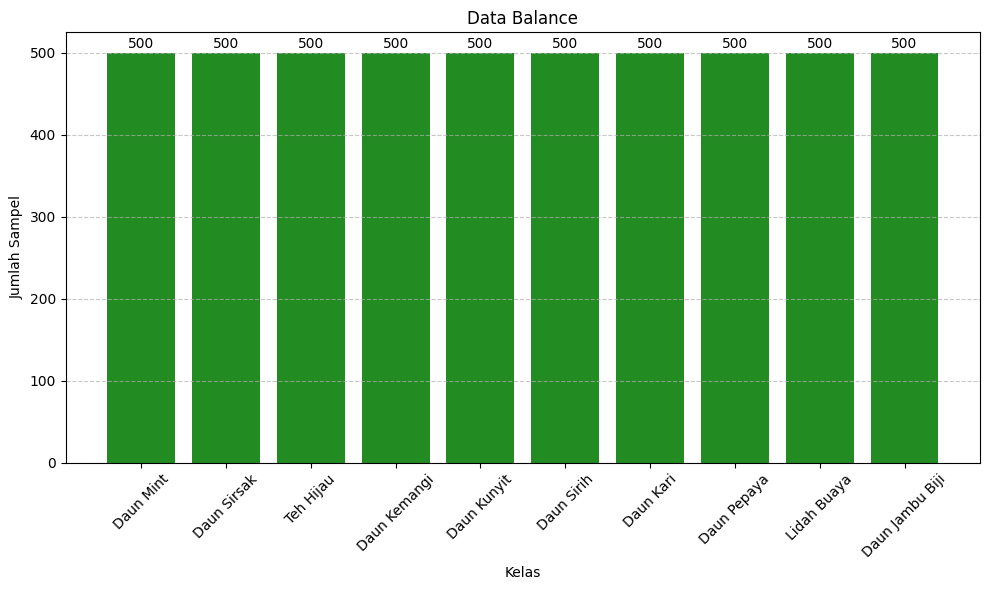

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(data_balance.index, data_balance.values, color="#228B22")  # Hijau daun
plt.title("Data Balance")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Sampel")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Label jumlah di atas batang
for i, v in enumerate(data_balance.values):
    plt.text(i, v + 2, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()


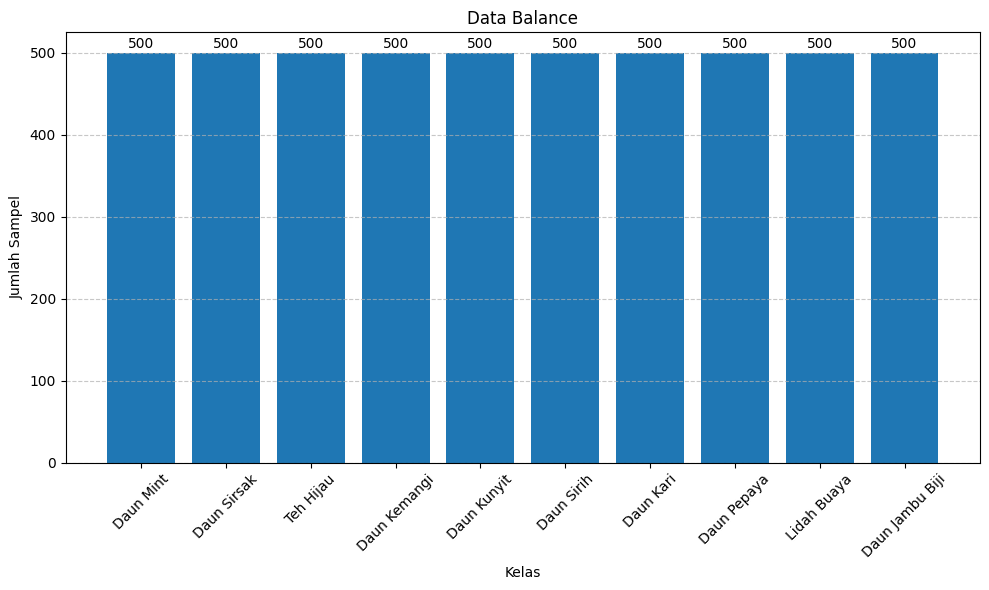

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(data_balance.index, data_balance.values, color="#1f77b4")  # Satu warna biru tua
plt.title("Data Balance")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Sampel")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Tambah label di atas batang (opsional)
for i, v in enumerate(data_balance.values):
    plt.text(i, v + 2, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()


In [ ]:
def custom_autopct(pct):
    total = sum(data_balance)
    val = int(round(pct*total/100.0))
    return "{:.1f}%\n({:d})".format(pct, val)

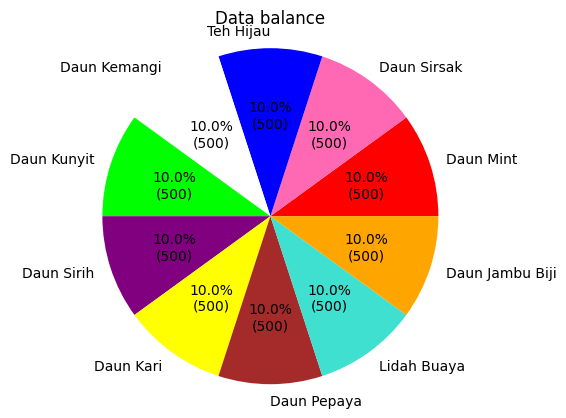

In [ ]:
plt.pie(data_balance, labels = data_balance.index, autopct=custom_autopct, colors = ["#FF0000", "#FF69B4", "#0000FF", "#FFFFFF", "#00FF00", "#800080", "#FFFF00", "#A52A2A", "#40E0D0", "#FFA500"])
plt.title("Data balance")
plt.axis("equal")
plt.show()

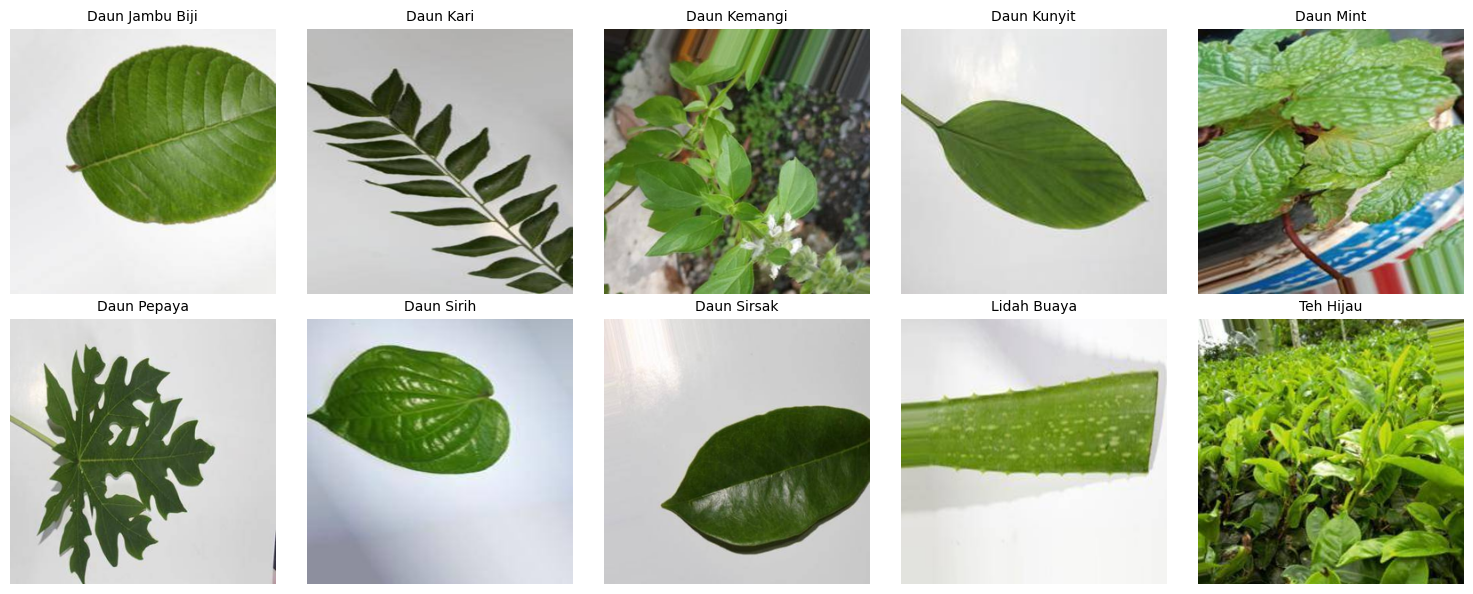

In [ ]:
dataset_dir = "/content/daun-tanaman-herbal/Dataset Tanaman Herbal/Daun Herbal/Dataset"

labels = set(os.listdir(dataset_dir))

all_labels = sorted(labels)
num_labels = len(all_labels)

num_rows = 2
num_cols = (num_labels + 1) // num_rows

img_size = (299, 299)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 6))

def get_random_image(label):
    label_path = os.path.join(dataset_dir, label)

    images = []
    if os.path.exists(label_path):
        images.extend([os.path.join(label_path, img) for img in os.listdir(label_path)])


    return random.choice(images) if images else None

for i, label in enumerate(all_labels):
    row, col = divmod(i, num_cols)
    img_path = get_random_image(label)

    if img_path:
        img = Image.open(img_path).resize(img_size)
        axes[row, col].imshow(img)
        axes[row, col].axis("off")
        axes[row, col].set_title(label, fontsize=10)

for j in range(i + 1, num_rows * num_cols):
    row, col = divmod(j, num_cols)
    fig.delaxes(axes[row, col])

plt.tight_layout()
plt.show()


# **Data Preparation**

## Pembagian Data

In [ ]:
train_df, ts_df = train_test_split(df, train_size = 0.8, shuffle = True, random_state = 42)

valid_df, test_df = train_test_split(ts_df, train_size = 0.5, shuffle = True, random_state = 42)

## Resize Data & Augmentasi

In [ ]:
batch_size = 16
img_size = (299, 299)

tr_gen = ImageDataGenerator(
    rescale=1. / 255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
)

ts_gen = ImageDataGenerator(rescale=1. / 255)

train_gen = tr_gen.flow_from_dataframe(train_df, x_col='path', y_col='labels',
                                       target_size=img_size, class_mode='categorical',
                                       color_mode='rgb', shuffle=True, batch_size=batch_size)

valid_gen = ts_gen.flow_from_dataframe(valid_df, x_col='path', y_col='labels',
                                       target_size=img_size, class_mode='categorical',
                                       color_mode='rgb', shuffle=True, batch_size=batch_size)

test_gen = ts_gen.flow_from_dataframe(test_df, x_col='path', y_col='labels',
                                      target_size=img_size, class_mode='categorical',
                                      color_mode='rgb', shuffle=False, batch_size=batch_size)


Found 4000 validated image filenames belonging to 10 classes.
Found 500 validated image filenames belonging to 10 classes.
Found 500 validated image filenames belonging to 10 classes.


### Hasil Augementasi

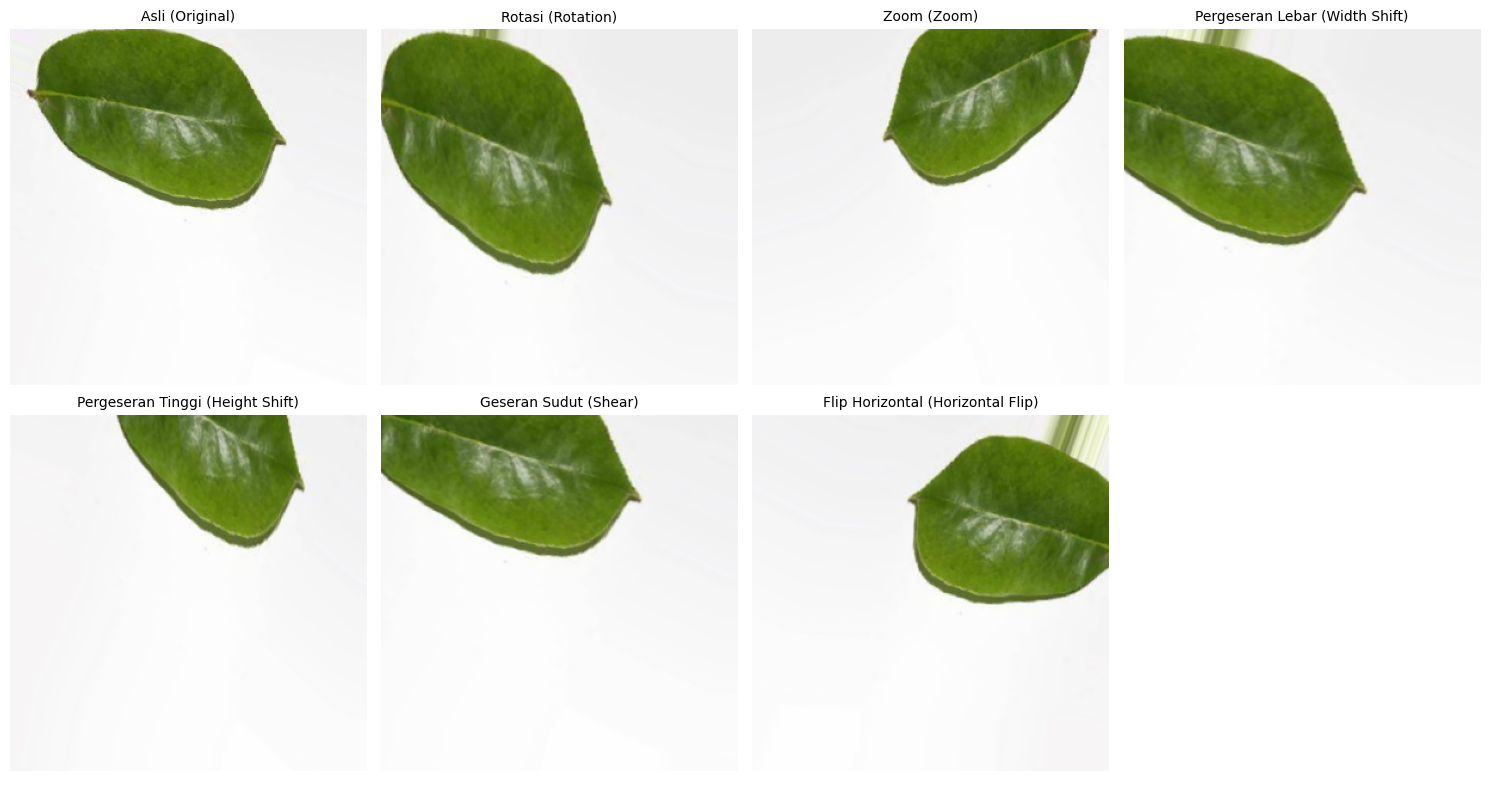

In [ ]:
# Ambil 1 batch gambar dari train_gen
images, labels = next(train_gen)

# Pilih 1 gambar untuk ditampilkan
idx = 0  # Index gambar pertama dalam batch
sample_image = images[idx]

augmentations = [
    ("Asli", "Original"),
    ("Rotasi", "Rotation"),
    ("Zoom", "Zoom"),
    ("Pergeseran Lebar", "Width Shift"),
    ("Pergeseran Tinggi", "Height Shift"),
    ("Geseran Sudut", "Shear"),
    ("Flip Horizontal", "Horizontal Flip"),
]

fig, axes = plt.subplots(2, 4, figsize=(15, 8))  # 2 baris, 4 kolom

for j in range(8):  # Loop tetap 8 agar layout rapi
    row, col = divmod(j, 4)  # Hitung posisi baris dan kolom

    if j < len(augmentations):  # Jika masih dalam jumlah augmentasi
        ind_label, eng_label = augmentations[j]
        if ind_label == "Asli":
            img = sample_image  # Gambar tanpa augmentasi
        else:
            img = train_gen.image_data_generator.random_transform(sample_image)

        img = (img * 255).astype(np.uint8)  # Konversi ke format gambar
        axes[row, col].imshow(img)
        axes[row, col].set_title(f"{ind_label} ({eng_label})", fontsize=10)
    else:
        # Slot kosong, biarkan tanpa gambar
        axes[row, col].axis("off")

    axes[row, col].axis("off")

plt.tight_layout()
plt.show()


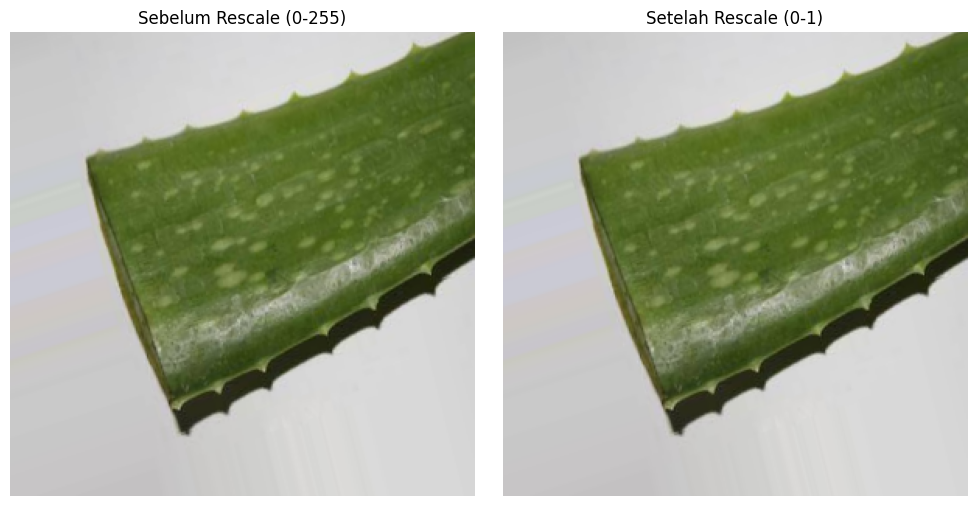

Nilai piksel sebelum rescale (0-255): [194 194 194]
Nilai piksel setelah rescale (0-1): [0.7607844 0.7607844 0.7607844]


In [ ]:
# Ambil 1 batch gambar dari train_gen
images, labels = next(train_gen)

# Pilih 1 gambar untuk ditampilkan
idx = 0  # Index gambar pertama dalam batch
sample_image = images[idx]  # Gambar yang sudah di-rescale (0-1)

# Mengembalikan gambar ke skala 0-255 untuk visualisasi perbandingan
original_image = (sample_image * 255).astype(np.uint8)

# Visualisasi sebelum dan sesudah rescale
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(original_image)
axes[0].set_title("Sebelum Rescale (0-255)")
axes[0].axis("off")

axes[1].imshow(sample_image)
axes[1].set_title("Setelah Rescale (0-1)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

# Print nilai piksel untuk melihat perbedaannya
print("Nilai piksel sebelum rescale (0-255):", original_image[0, 0, :])
print("Nilai piksel setelah rescale (0-1):", sample_image[0, 0, :])


# **Modelling**

In [ ]:
# Load model dasar
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(299, 299, 3))
base_model.trainable = False  # Bekukan layer pre-trained

# Model sederhana untuk dataset kecil
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu', kernel_regularizer=l2(0.0001)),
    Dropout(0.3),
    Dense(10, activation="softmax")
])

# Compile model
model.compile(optimizer=Adamax(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Print ringkasan model
model.summary()

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 8, 8, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,066,346 (84.18 MB)

 Trainable params: 263,562 (1.01 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

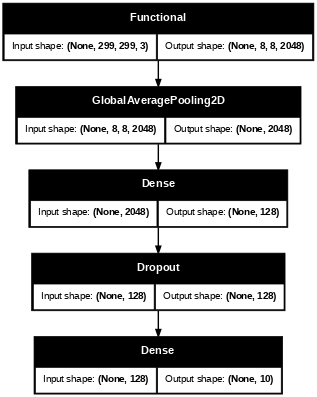

In [ ]:
plot_model(model,
           show_shapes=True,
           dpi=50)  # Perkecil ukuran plot

In [ ]:
# Set up early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Fit the model with early stopping
epochs = 20
InceptionV3_history = model.fit(train_gen,
                                             epochs=epochs,
                                             verbose=1,
                                             validation_data=valid_gen,
                                             shuffle=False,
                                             callbacks=[early_stopping])

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 118s 400ms/step - accuracy: 0.3435 - loss: 2.0209 - val_accuracy: 0.8460 - val_loss: 1.0975
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 88s 350ms/step - accuracy: 0.7563 - loss: 1.0827 - val_accuracy: 0.9120 - val_loss: 0.6356
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 142s 349ms/step - accuracy: 0.8527 - loss: 0.6912 - val_accuracy: 0.9500 - val_loss: 0.4383
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 87s 350ms/step - accuracy: 0.8874 - loss: 0.5171 - val_accuracy: 0.9560 - val_loss: 0.3288
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 88s 350ms/step - accuracy: 0.9148 - loss: 0.4192 - val_accuracy: 0.9620 - val_loss: 0.2661
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 88s 351ms/step - accuracy: 0.9250 - loss: 0.3399 - val_accuracy: 0.9660 - val_loss: 0.2262
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 88s 351ms/step - accuracy: 0.9343 - loss: 0.3038 - val_accuracy: 0.9660 - val_loss: 0.1958
Epoch 8/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 88s 352ms/step - accuracy: 0.9375 - loss:

# **Evaluation**

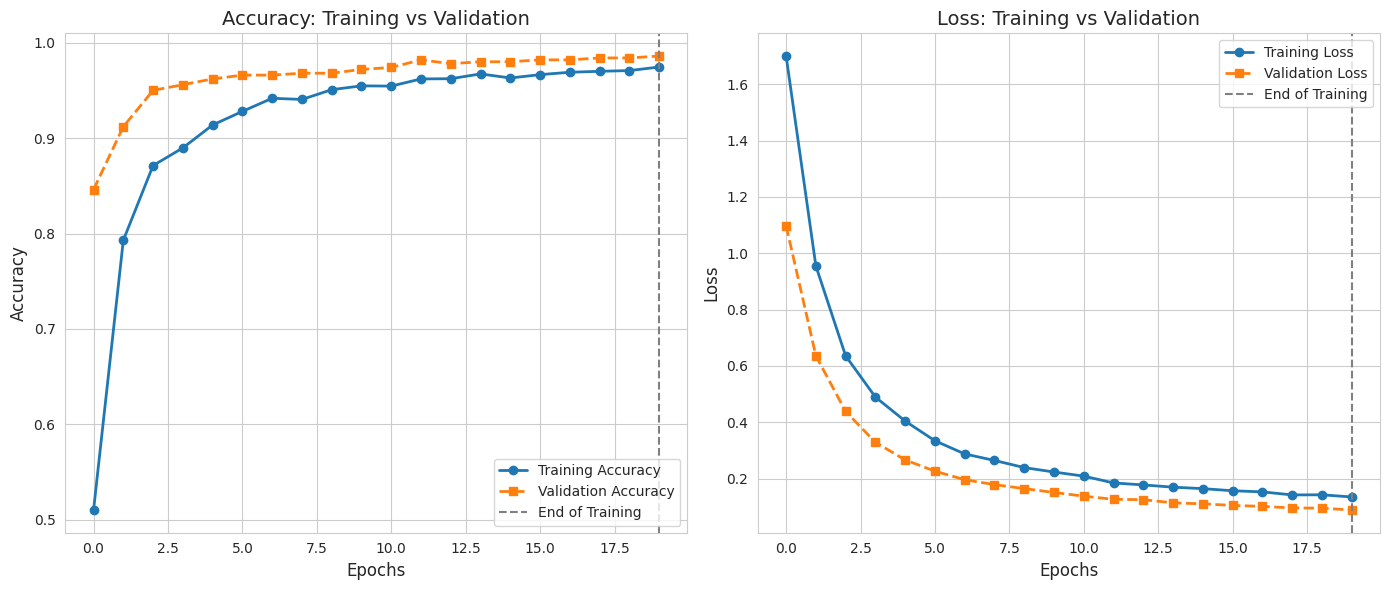

In [ ]:
def model_evaluation(model, history):
    # Evaluasi model pada data uji
    test_loss, test_accuracy = model.evaluate(test_gen, verbose=0)

    sns.set_style("whitegrid")
    plt.figure(figsize=(14, 6))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o', linestyle='-', linewidth=2)
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s', linestyle='--', linewidth=2)
    plt.axvline(x=len(history.history['accuracy'])-1, color='gray', linestyle='--', label='End of Training')
    plt.xlabel("Epochs", fontsize=12)
    plt.ylabel("Accuracy", fontsize=12)
    plt.legend(loc='lower right', fontsize=10)
    plt.title('Accuracy: Training vs Validation', fontsize=14)

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss', marker='o', linestyle='-', linewidth=2)
    plt.plot(history.history['val_loss'], label='Validation Loss', marker='s', linestyle='--', linewidth=2)
    plt.axvline(x=len(history.history['loss'])-1, color='gray', linestyle='--', label='End of Training')
    plt.xlabel("Epochs", fontsize=12)
    plt.ylabel("Loss", fontsize=12)
    plt.legend(loc='upper right', fontsize=10)
    plt.title('Loss: Training vs Validation', fontsize=14)

    plt.tight_layout()
    plt.show()

# Pastikan history model tersedia sebelum memanggil fungsi
if 'InceptionV3_history' in locals() and InceptionV3_history.history:
    model_evaluation(model, InceptionV3_history)
else:
    print("Error: 'InceptionV3_history' tidak ditemukan. Pastikan model.fit() sudah dijalankan.")


In [ ]:
def model_evaluation(model):
    train_score = model.evaluate(train_gen, verbose= 1)
    valid_score = model.evaluate(valid_gen, verbose= 1)
    test_score = model.evaluate(test_gen, verbose= 1)

    print("Train Loss: ", train_score[0])
    print("Train Accuracy: ", train_score[1])
    print('-' * 20)
    print("Validation Loss: ", valid_score[0])
    print("Validation Accuracy: ", valid_score[1])
    print('-' * 20)
    print("Test Loss: ", test_score[0])
    print("Test Accuracy: ", test_score[1])

model_evaluation(model)

250/250 ━━━━━━━━━━━━━━━━━━━━ 85s 339ms/step - accuracy: 0.9828 - loss: 0.0967
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.9850 - loss: 0.0864
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.9834 - loss: 0.0738
Train Loss:  0.09749104827642441
Train Accuracy:  0.9854999780654907
--------------------
Validation Loss:  0.08822587132453918
Validation Accuracy:  0.9860000014305115
--------------------
Test Loss:  0.0837419256567955
Test Accuracy:  0.984000027179718


32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 242ms/step


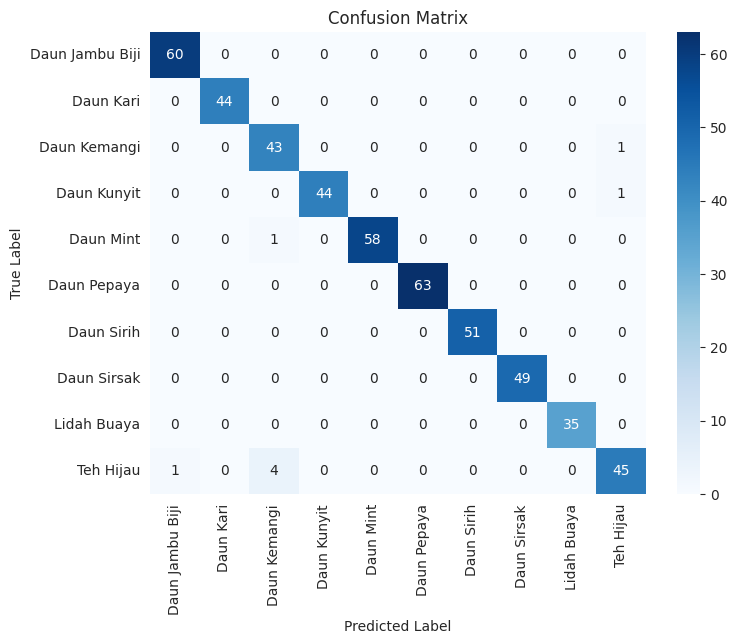

Classification Report:
                 precision    recall  f1-score   support

Daun Jambu Biji       0.98      1.00      0.99        60
      Daun Kari       1.00      1.00      1.00        44
   Daun Kemangi       0.90      0.98      0.93        44
    Daun Kunyit       1.00      0.98      0.99        45
      Daun Mint       1.00      0.98      0.99        59
    Daun Pepaya       1.00      1.00      1.00        63
     Daun Sirih       1.00      1.00      1.00        51
    Daun Sirsak       1.00      1.00      1.00        49
    Lidah Buaya       1.00      1.00      1.00        35
      Teh Hijau       0.96      0.90      0.93        50

       accuracy                           0.98       500
      macro avg       0.98      0.98      0.98       500
   weighted avg       0.98      0.98      0.98       500



In [ ]:
# Fungsi untuk mendapatkan prediksi
def get_pred(model, generator):
    y_true = generator.classes  # Label asli
    y_pred_probs = model.predict(generator)  # Probabilitas prediksi
    y_pred = np.argmax(y_pred_probs, axis=1)  # Ambil kelas dengan probabilitas tertinggi
    return y_true, y_pred

# Fungsi untuk menampilkan confusion matrix & laporan klasifikasi
def evaluate_model(model, generator):
    y_true, y_pred = get_pred(model, generator)

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    labels = list(generator.class_indices.keys())

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

    # Classification Report
    print("Classification Report:")
    print(classification_report(y_true, y_pred, target_names=labels))

# ✅ Evaluasi model menggunakan test_gen
evaluate_model(model, test_gen)

1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step


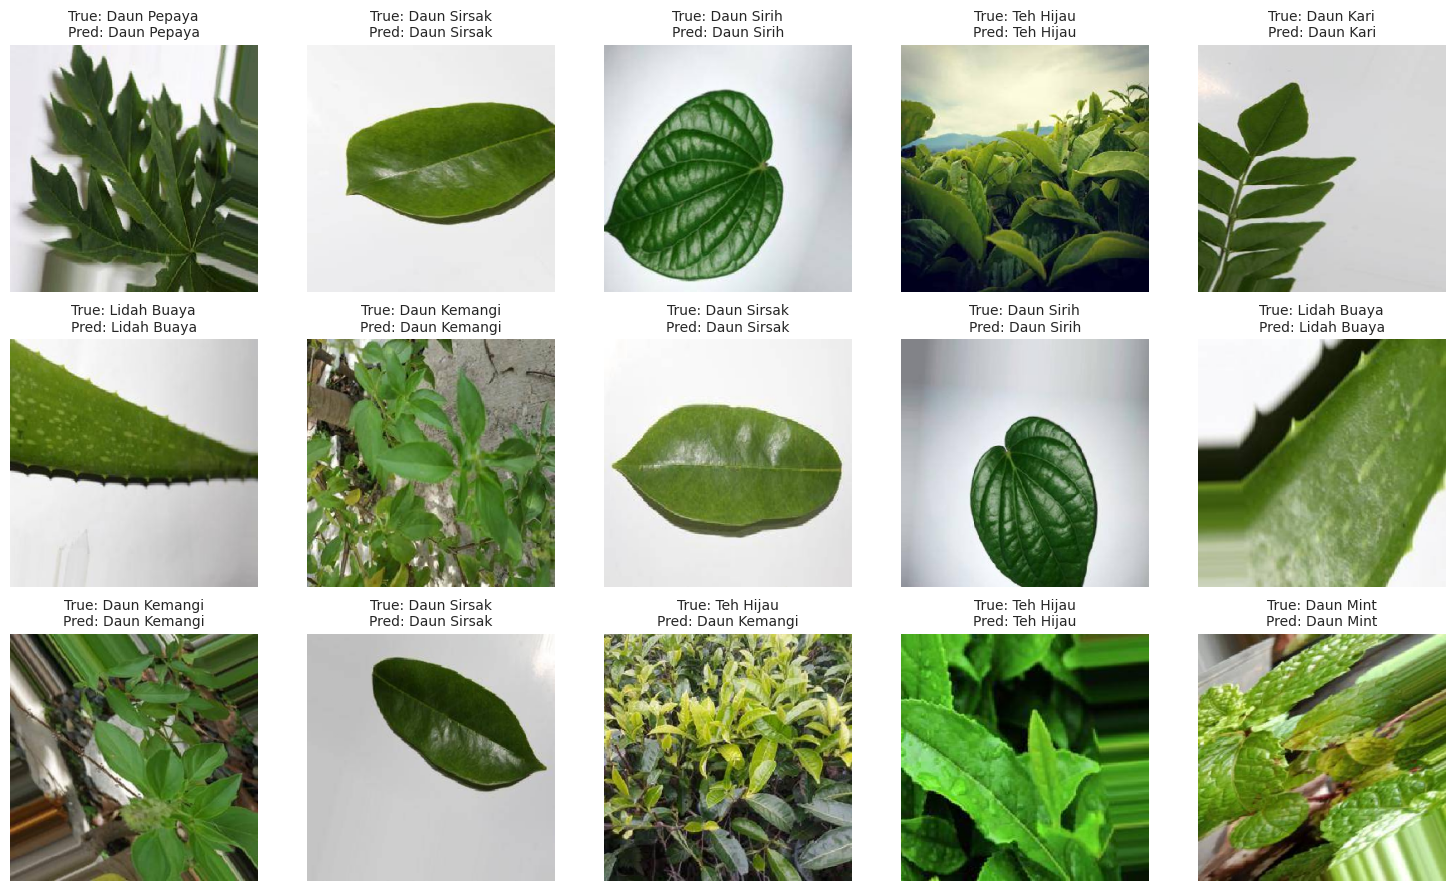

In [ ]:
# Pastikan class_labels sesuai dengan test_generator
class_labels = list(test_gen.class_indices.keys())

# Tentukan jumlah gambar yang akan ditampilkan
num_images = 20
num_images_per_row = 5

# Ambil batch pertama dari test_generator
batch_images, batch_labels = next(iter(test_gen))

# Pastikan tidak melebihi jumlah batch yang tersedia
num_images = min(num_images, len(batch_images))

# **Agar pas, pastikan num_images adalah kelipatan num_images_per_row**
num_images = (num_images // num_images_per_row) * num_images_per_row  # Bulatkan ke bawah

# Jika jumlah gambar setelah pembulatan jadi 0, pakai minimal 1 baris penuh
if num_images == 0:
    num_images = min(len(batch_images), num_images_per_row)

# Hitung jumlah baris
num_rows = num_images // num_images_per_row

# Prediksi model
predictions = model.predict(batch_images[:num_images])

# Buat plot
plt.figure(figsize=(15, num_rows * 3))

for i in range(num_images):
    predicted_class = class_labels[np.argmax(predictions[i])]
    true_class = class_labels[np.argmax(batch_labels[i])]

    plt.subplot(num_rows, num_images_per_row, i + 1)
    plt.imshow(batch_images[i])  # Gambar sudah dalam skala 0-1
    plt.title(f'True: {true_class}\nPred: {predicted_class}', fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()

# **Deployment**

In [ ]:
# Convert the Keras model to TensorFlow Lite model
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save the TFLite model to a file
with open('Daun1.tflite', 'wb') as f:
    f.write(tflite_model)

print("Model converted to TFLite and saved as 'Daun1.tflite'")


Saved artifact at '/tmp/tmp3nft5iue'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 299, 299, 3), dtype=tf.float32, name='keras_tensor_311')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  134859195671632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134859195667600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134859195672208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134859195666256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134859195668368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134859195665872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134859195671824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134859195666832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134859195666448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134859195822544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134859195

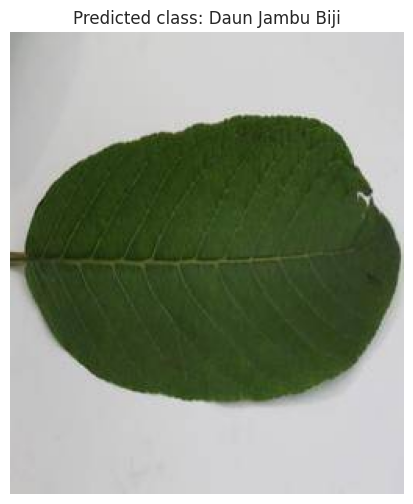

In [ ]:
# Load TFLite model
interpreter = tf.lite.Interpreter(model_path='/content/Daun1.tflite')
interpreter.allocate_tensors()

class_names = ['Daun Jambu Biji', 'Daun Kari', 'Daun Kemangi', 'Daun Kunyit',
               'Daun Mint', 'Daun Pepaya', 'Daun Sirih', 'Daun Sirsak', 'Lidah Buaya', 'Teh Hijau']

def preprocess_image(image_path):
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError(f"Gambar tidak ditemukan atau tidak bisa dibaca: {image_path}")

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (299, 299)) / 255.0
    return np.expand_dims(image.astype(np.float32), axis=0)

def make_prediction(image_path):
    input_data = preprocess_image(image_path)
    interpreter.set_tensor(interpreter.get_input_details()[0]['index'], input_data)
    interpreter.invoke()
    output_data = interpreter.get_tensor(interpreter.get_output_details()[0]['index'])
    predicted_class = class_names[np.argmax(output_data)]

    # Pastikan gambar bisa dibaca sebelum ditampilkan
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError(f"Gambar tidak ditemukan atau tidak bisa dibaca saat menampilkan: {image_path}")

    return predicted_class, cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

image_path = '/content/daun-tanaman-herbal/Dataset Tanaman Herbal/Daun Herbal/Dataset/Daun Jambu Biji/Daun Jambu Biji 100.jpg'
predicted_class, image_rgb = make_prediction(image_path)

plt.figure(figsize=(6, 6))
plt.imshow(image_rgb)
plt.title(f"Predicted class: {predicted_class}")
plt.axis('off')
plt.show()
